# Setup

In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging
import tpvalidator.workspace as workspace
import tpvalidator.utils as utils
import tpvalidator.analyzers.snn as snn

from rich import print
from tpvalidator.utils import temporary_log_level, pandas_backend

from collections import OrderedDict

## Code

In [3]:
def make_wins(tps: pd.DataFrame, ro_view: int):
    summary = (
        tps
        .query(f'readout_view == {ro_view}')
        .groupby(['event_uid', 'TPCSetID', 'tawin_id'], sort=False)
        .agg(
            n_entries=('tawin_id', "size"),
            sadc=("adc_integral", "sum"),
        )
        .reset_index()
    )

    return summary




## Data

In [4]:
import tpvalidator.datasets.miniprod as miniprod

datasets = miniprod.load_tp_presel_datasets()

Key 'triggerAna/mcneutrinos' not found in file.
Key 'triggerAna/mcparticles' not found in file.
Key 'triggerAna/simides' not found in file.


Dataset 'e-minus': 4920 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Dataset 'gammas': 4950 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Dataset 'mu-minus': 4930 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

Dataset 'radbkg': 9930 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

/var/folders/dw/sj94s2457kl2gkb829ty4_cc0000gn/T/ipykernel_77518/2615817058.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  rad_tps.hist(ax=ax)


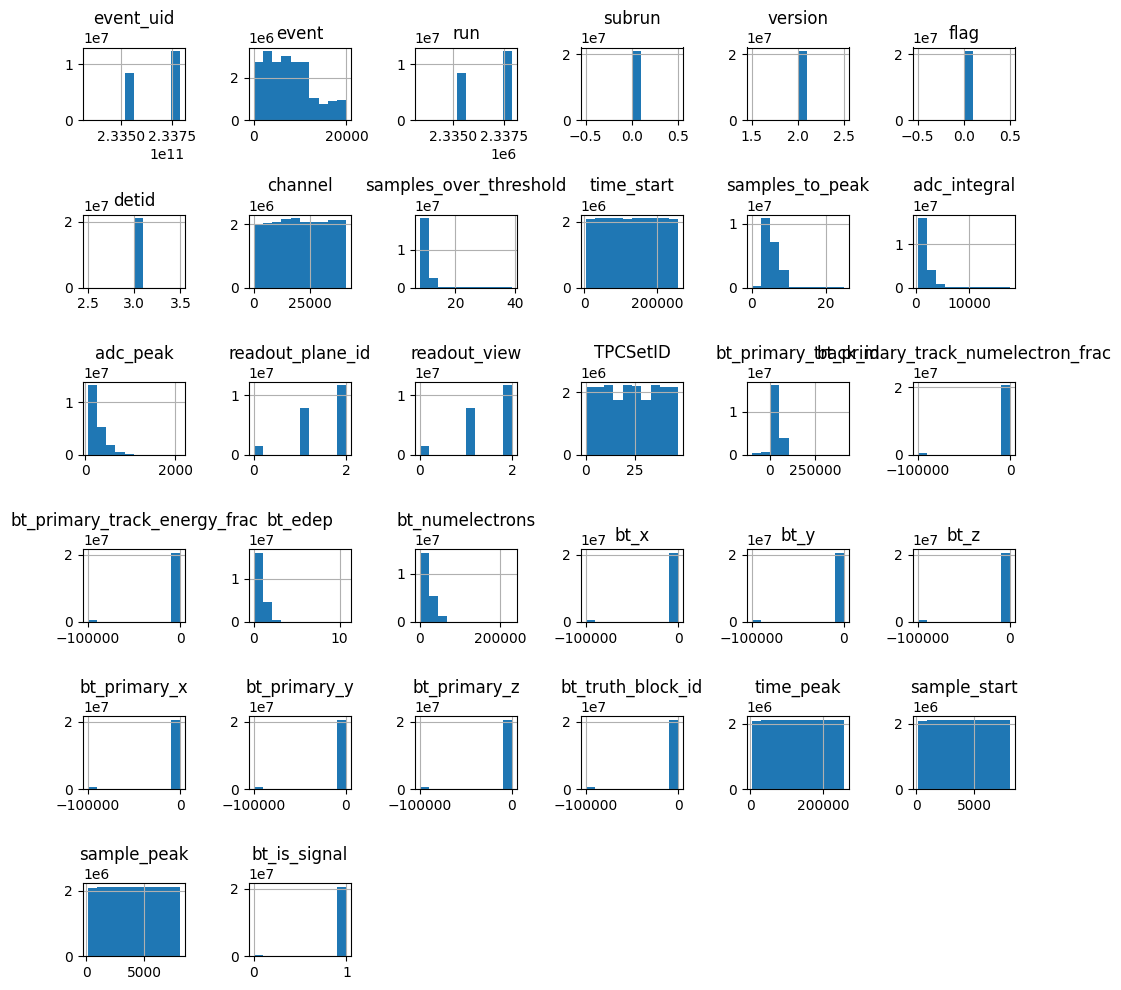

In [5]:
rad_tps = datasets['radbkg'].tps

fig, ax = plt.subplots(figsize=(10,10))
rad_tps.hist(ax=ax)
fig.tight_layout()

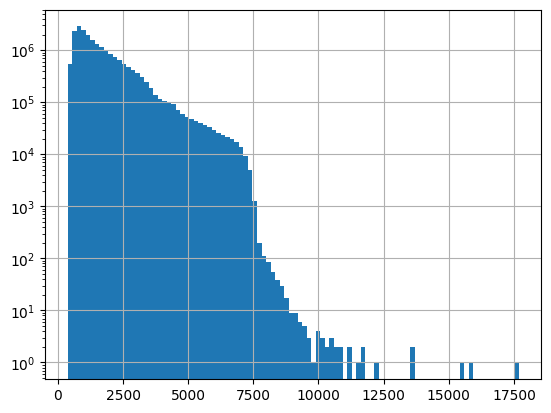

In [6]:
fig, axes = plt.subplots()
ax = axes
rad_tps.adc_integral.hist(bins=100, ax=ax)
ax.set_yscale('log')

Simulated time 39.72 s

Text(0.5, 0.98, 'TP variables distributions for the 10 highest backgrounds')

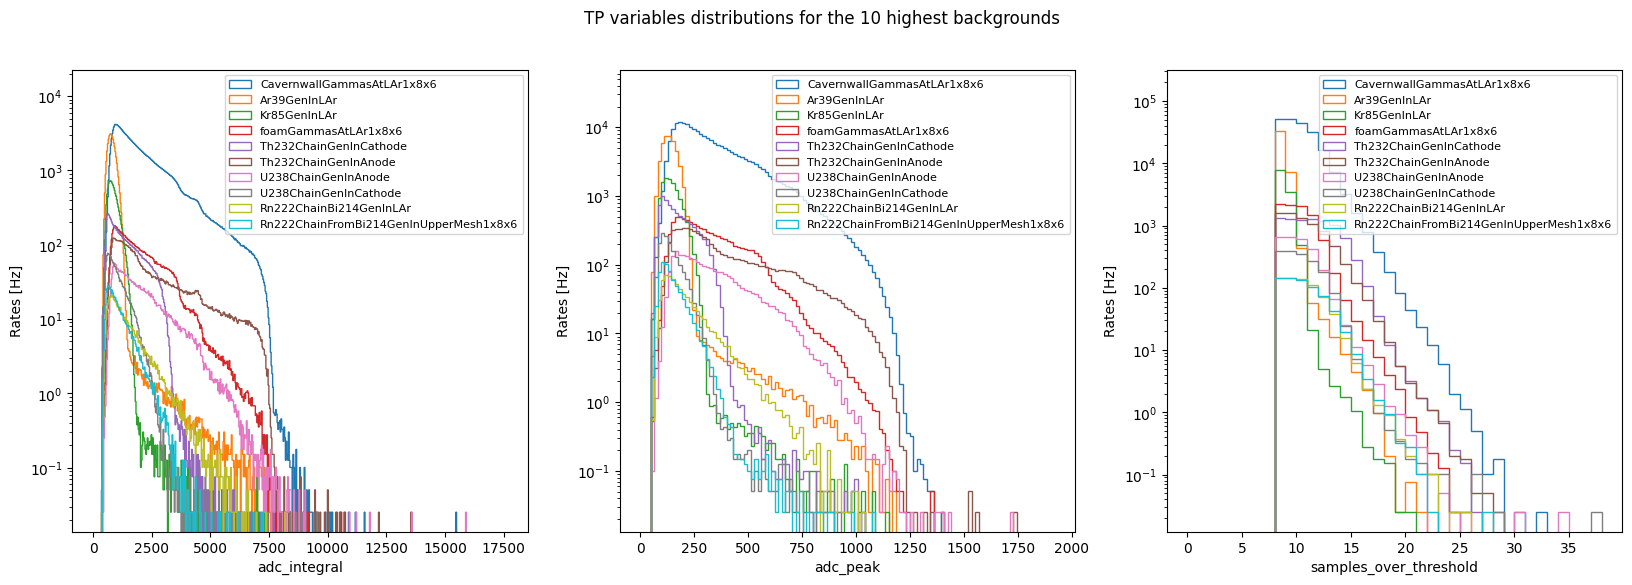

In [7]:
def plot_bkg_tpcounts_by_genname(tps, ax, var='adc_integral', binsize=8, scale=1, ylabel='counts'):

    num_bkg = 10
    tps_by_gen = sorted([(n,df) for n,df in tps.groupby('bt_generator_name')], reverse=True, key=lambda x: len(x[1]))
    top_by_gen = tps_by_gen[:num_bkg]


    bin_max = max([df[var].max() for _, df in top_by_gen])

    bins=np.arange(0, int(bin_max), binsize)

    for n,df in top_by_gen:
        ax.hist(df[var], bins=bins, histtype='step', weights=np.ones(len(df))*scale, label=n if n else 'noise')
        # ax.hist(df[var], bins=bins, histtype='step', weights=df['adc_integral'], label=n if n else 'noise')
    ax.legend(prop={'size': 8})
    ax.set_yscale('log')
    ax.set_xlabel(var)
    ax.set_ylabel(ylabel)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, 3*ymax)



fig, axes = plt.subplots(1,3, figsize=(20,6))
ro_view = 2
rad_tps_view = rad_tps.query(f'readout_view == {ro_view}')
sim_time = rad_tps_view.extra_info['num_entries']*rad_tps_view.extra_info['readout_window']*0.5e-6
print(f"Simulated time {sim_time:.2f} s")

ax = axes[0]
plot_bkg_tpcounts_by_genname(rad_tps_view, var='adc_integral', binsize=32, ax =ax, scale=1/sim_time, ylabel='Rates [Hz]')
ax = axes[1]
plot_bkg_tpcounts_by_genname(rad_tps_view, var='adc_peak', binsize=16, ax =ax, scale=1/sim_time, ylabel='Rates [Hz]')
ax = axes[2]
plot_bkg_tpcounts_by_genname(rad_tps_view, var='samples_over_threshold', binsize=1, ax =ax, scale=1/sim_time, ylabel='Rates [Hz]')
fig.suptitle("TP variables distributions for the 10 highest backgrounds")

In [8]:
from typing import Tuple, Optional, Union, Sequence, Dict, List
from rich.table import Table
from tpvalidator.detector_geometry import FDVDGeometry_1x6x8

def make_rates_table_from_dataframes(
        datasets : Dict[str,pd.DataFrame],
        preselection: str = '',
        per:str='chan',
        title: str='',
        ro_win_len: int=None,
        sampling_period=0.5e-6
        ) -> Table:

    num_el_map = {
        'chan' : lambda v: FDVDGeometry_1x6x8.crp_num_chans_by_view_sim(v)*FDVDGeometry_1x6x8.num_crps,
        'crp' : lambda _: FDVDGeometry_1x6x8.num_crps,
        'tpc' : lambda _: FDVDGeometry_1x6x8.num_tpcs,
        'det' : lambda _: 1,
        'fdvd' : lambda _: FDVDGeometry_1x6x8.num_crps/160,
    }

    num_el = num_el_map[per]

    t = Table('sample', 'time', 'U', 'V', 'X', title=title)
    for s, df in datasets.items():
        # num_ev = num_events
        num_ev = df.extra_info['num_entries']

        
        # Throw if not available
        ro_win_len = df.extra_info['readout_window'] if ro_win_len is None else ro_win_len

        total_time = num_ev*ro_win_len*sampling_period
        row = [s, f'{total_time:.3f} s']
        tps_sel = df.query(preselection) if preselection else df
        for v in range(3):
            num_els = num_el(v)
            noise_rate = len(tps_sel.query(f'readout_view == {v}'))/total_time/num_els
            row += [f'{noise_rate:.2f} Hz']
        t.add_row(*row)
    return t

In [9]:
rad_tps_by_gen = sorted([(n if n else 'Noise',df) for n,df in rad_tps.groupby('bt_generator_name')], reverse=True, key=lambda x: len(x[1]))


In [10]:

print(make_rates_table_from_dataframes(OrderedDict([('radbkg', rad_tps)]), per='tpc', title='Rates per TPC'))
print(make_rates_table_from_dataframes(OrderedDict(rad_tps_by_gen), per='tpc', title='Rates per TPC'))


                       Rates per TPC                       
┏━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ sample ┃ time     ┃ U         ┃ V          ┃ X          ┃
┡━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ radbkg │ 39.720 s │ 796.45 Hz │ 4132.56 Hz │ 6123.12 Hz │
└────────┴──────────┴───────────┴────────────┴────────────┘

                                       Rates per TPC                                       
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ sample                                 ┃ time     ┃ U         ┃ V          ┃ X          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ CavernwallGammasAtLAr1x8x6             │ 39.720 s │ 600.91 Hz │ 3351.82 Hz │ 4359.05 Hz │
│ Ar39GenInLAr                           │ 39.720 s │ 1.13 Hz   │ 67.97 Hz   │ 845.40 Hz  │
│ Th232ChainGenInCathode                 │ 39.720 s │ 71.49 Hz  │ 102.54 Hz  │ 173.76 Hz  │
│ foamGammasAtLAr1x8x6                   │ 39.720 s │ 15.09 Hz  │ 139.93 Hz  │ 182.10 Hz  │
│ Th232ChainGenInAnode                   │ 39.720 s │ 38.11 Hz  │ 122.87 Hz  │ 153.28 Hz  │
│ Kr85GenInLAr                           │ 39.720 s │ 0.15 Hz   │ 39.64 Hz   │ 243.12 Hz  │
│ Noise                                  │ 39.720 s │ 39.62 Hz  │ 207.47 Hz  │ 0.42 Hz    │
│ U238ChainGenInAnode                    │ 39.720 s │ 5.75 Hz   │ 42.49 Hz   │ 55.11 Hz   │
│ U238ChainGenInCathode                  │ 39.720 s │ 7.31 Hz   │ 15.00 Hz   │ 35.34 Hz   │
│ Rn222ChainBi214GenInLAr                │ 39.720 s │ 3.27 Hz   │ 8.49 Hz    │ 14.06 Hz   │
│ Rn222ChainFromBi214GenInUpperMesh1x8x6 │ 39.720 s │ 3.50 Hz   │ 6.40 Hz    │ 14.01 Hz   │
│ Rn220ChainFromPb212GenInUpperMesh1x8x6 │ 39.720 s │ 4.42 Hz   │ 6.79 Hz    │ 12.33 Hz   │
│ K40GenInAnode                          │ 39.720 s │ 0.30 Hz   │ 9.72 Hz    │ 12.98 Hz   │
│ Rn220ChainPb212GenInLAr                │ 39.720 s │ 3.20 Hz   │ 6.28 Hz    │ 8.64 Hz    │
│ K40GenInCathode                        │ 39.720 s │ 0.73 Hz   │ 2.50 Hz    │ 6.74 Hz    │
│ K42From42ArGenInUpperMesh1x8x6         │ 39.720 s │ 1.13 Hz   │ 1.57 Hz    │ 2.48 Hz    │
│ Rn222ChainFromBi210GenInUpperMesh1x8x6 │ 39.720 s │ 0.02 Hz   │ 0.20 Hz    │ 1.74 Hz    │
│ Rn222ChainPb214GenInLAr                │ 39.720 s │ 0.01 Hz   │ 0.32 Hz    │ 1.55 Hz    │
│ K42From42ArGenInLAr                    │ 39.720 s │ 0.29 Hz   │ 0.50 Hz    │ 0.63 Hz    │
│ Rn222ChainFromPb214GenInUpperMesh1x8x6 │ 39.720 s │ 0.00 Hz   │ 0.02 Hz    │ 0.22 Hz    │
│ Ar42GenInLAr                           │ 39.720 s │ 0.00 Hz   │ 0.01 Hz    │ 0.13 Hz    │
│ Rn222ChainRn222GenInLAr                │ 39.720 s │ 0.00 Hz   │ 0.00 Hz    │ 0.01 Hz    │
│ Rn222ChainPo218GenInLAr                │ 39.720 s │ 0.00 Hz   │ 0.00 Hz    │ 0.01 Hz    │
│ Rn222ChainFromPb210GenInUpperMesh1x8x6 │ 39.720 s │ 0.00 Hz   │ 0.00 Hz    │ 0.00 Hz    │
│ Rn222ChainPb210GenInLAr                │ 39.720 s │ 0.00 Hz   │ 0.00 Hz    │ 0.00 Hz    │
└────────────────────────────────────────┴──────────┴───────────┴────────────┴────────────┘

# Activity Search Windows

In [11]:
# Add TA search window id

em_tps = datasets['e-minus'].tps
rad_tps = datasets['radbkg'].tps
# print(len(em_tps))
# print(len(rad_tps))
# em_tps = datasets['e-minus'].tps.query('adc_peak > 100').copy()
# rad_tps = datasets['radbkg'].tps.query('adc_peak > 100').copy()
# print(len(em_tps))
# print(len(rad_tps))

win_size = 1000 # samples

em_tps['tawin_id'] = (em_tps.sample_peak - 100) // win_size
rad_tps['tawin_id'] = (rad_tps.sample_peak - 100) // win_size

<Axes: >

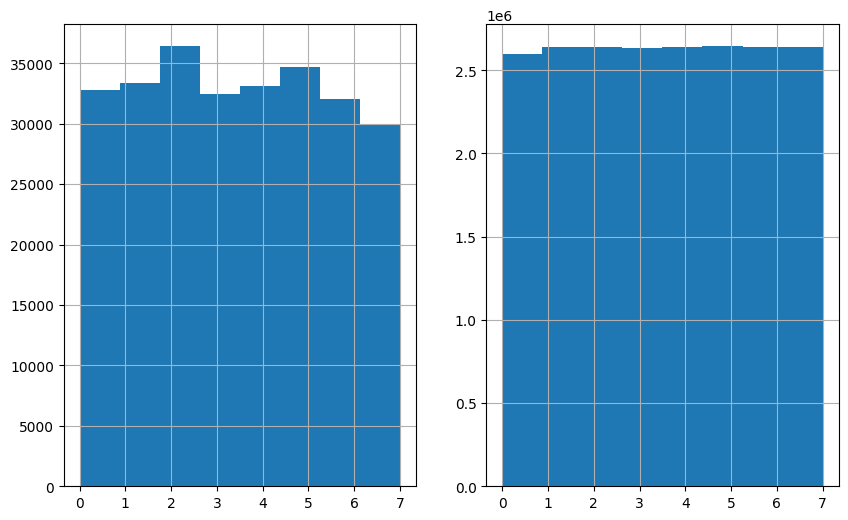

In [12]:
fig, axes = plt.subplots(1,2, figsize=(10,6))

em_tps.tawin_id.hist(bins=len(em_tps.tawin_id.unique()), ax=axes[0])
rad_tps.tawin_id.hist(bins=len(rad_tps.tawin_id.unique()), ax=axes[1])

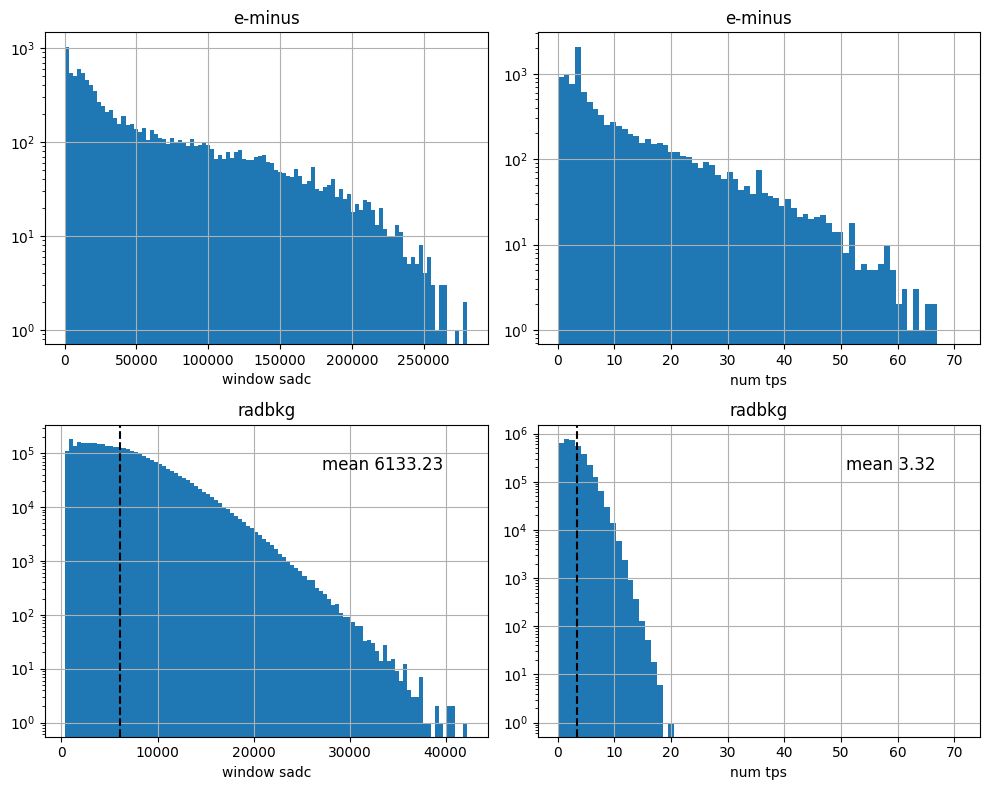

In [13]:
# 
em_wins = make_wins(em_tps, 2)
rad_wins = make_wins(rad_tps, 2)


fig, axes = plt.subplots(2,2, figsize=(10,8))

ax=axes[0][0]
em_wins.sadc.hist(ax=ax, bins=100)
ax.set_yscale('log')
ax.set_xlabel('window sadc')
ax.set_title('e-minus')


ax=axes[1][0]
rad_wins.sadc.hist(ax=ax, bins=100)
ax.set_yscale('log')
ax.set_xlabel('window sadc')
ax.set_title('radbkg')

ax.axvline(rad_wins.sadc.mean(), c='k', ls='--')
ax.text(0.9, 0.9, f"mean {rad_wins.sadc.mean():.2f}", transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right')

ax=axes[0][1]
em_wins.n_entries.hist(ax=ax, bins=np.linspace(0,71,70))
ax.set_yscale('log')
ax.set_xlabel('num tps')
ax.set_title('e-minus')

ax=axes[1][1]
rad_wins.n_entries.hist(ax=ax, bins=np.linspace(0,71,70))
ax.set_yscale('log')
ax.set_xlabel('num tps')
ax.set_title('radbkg')

ax.axvline(rad_wins.n_entries.mean(), c='k', ls='--')
# ax.text(rad_wins.n_entries.mean(), 1e5, f"mean {rad_wins.n_entries.mean()}")
# make_wins(rad_tps, 2)

ax.text(0.9, 0.9, f"mean {rad_wins.n_entries.mean():.2f}", transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right')

fig.tight_layout()

Number of actiity search windows: 3512416

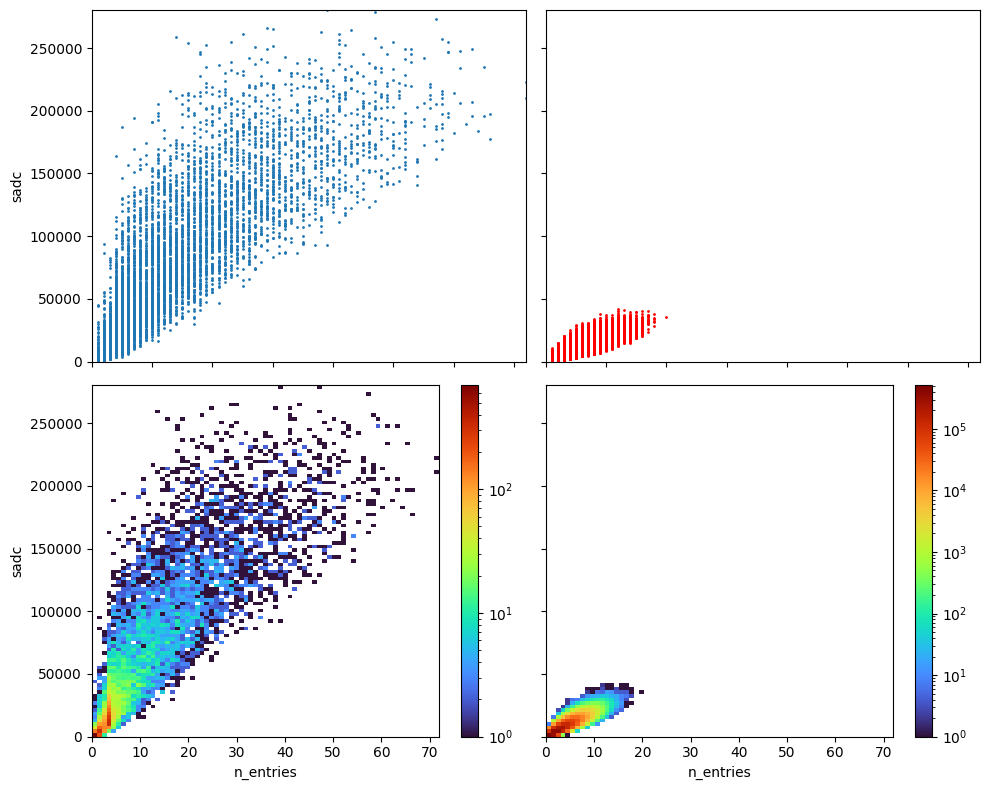

In [14]:
from matplotlib.colors import LogNorm

print(f"Number of actiity search windows: {len(rad_wins)}")

fig, axes = plt.subplots(2, 2, figsize=(10,8), sharex=True, sharey=True)
ax=axes[0][0]
em_wins.plot.scatter(x='n_entries', y='sadc', ax=ax, s=1)
ax.set_xlabel('n_entries')
ax.set_ylabel('sadc')

ax=axes[0][1]
rad_wins.plot.scatter(x='n_entries', y='sadc', ax=ax, c='r', s=1)
ax.set_xlabel('n_entries')
ax.set_ylabel('sadc')

# fig, axes = plt.subplots(1, 2, figsize=(13,6), sharex=True, sharey=True)
# bins= np.linspace(0,70,70),100
xmax = max(em_wins.n_entries.max(), rad_wins.n_entries.max())
ymax = max(em_wins.sadc.max(), rad_wins.sadc.max())
bins=(np.linspace(0,xmax,xmax), np.linspace(0,ymax,100))
cmap='turbo'
# cmap='viridis'
ax = axes[1][0]
h = ax.hist2d(em_wins['n_entries'], em_wins['sadc'], bins=bins, cmap=cmap, norm=LogNorm())
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('n_entries')
ax.set_ylabel('sadc')

ax = axes[1][1]
h = ax.hist2d(rad_wins['n_entries'], rad_wins['sadc'], bins=bins, cmap=cmap, norm=LogNorm())
fig.colorbar(h[3], ax=ax)
ax.set_xlabel('n_entries')
ax.set_ylabel('sadc')

# h = ax.hist2d(em_wins['n_entries'], em_wins['sadc'], bins=bins, cmap=cmap, weights=w, norm=LogNorm())
fig.tight_layout()

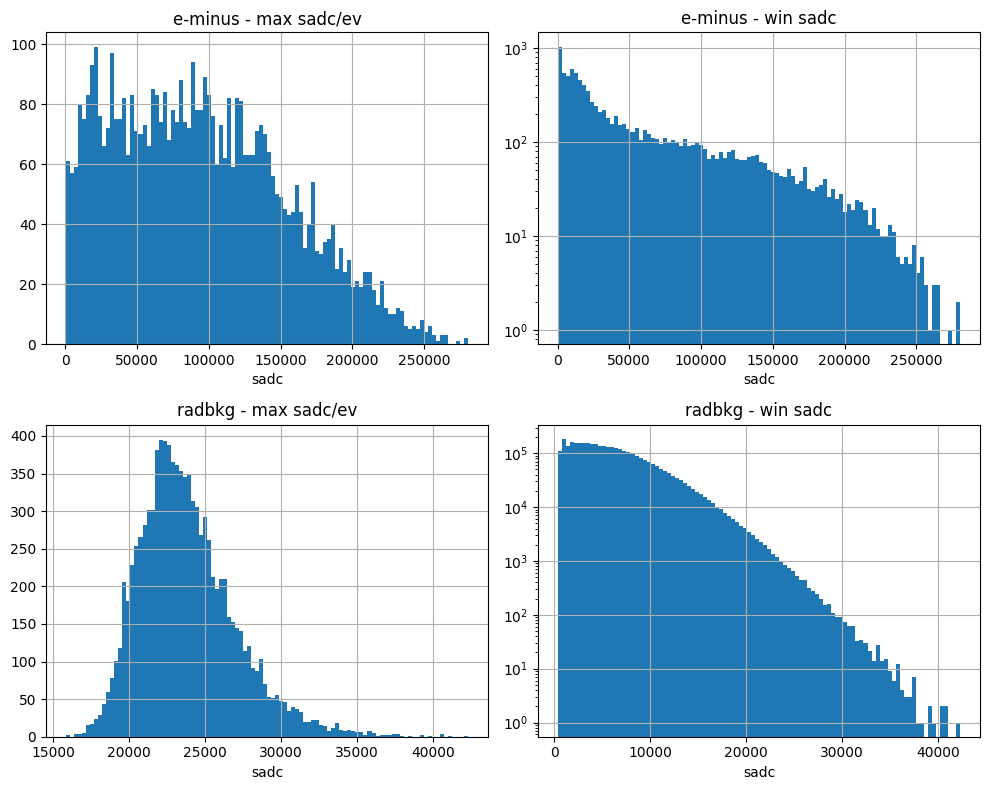

In [15]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

ax=axes[0][0]
(em_wins
#  .query('sadc > 4000')
 .groupby('event_uid', sort=False)
 .agg(
    sadc_max=('sadc', "max"),
    n_win=('tawin_id', "size"),
    )
).sadc_max.hist(bins=100, ax=ax)

ax.set_title('e-minus - max sadc/ev')
ax.set_xlabel('sadc')

ax=axes[1][0]

(rad_wins
#  .query('sadc > 4000')
 .groupby('event_uid', sort=False)
 .agg(
    sadc_max=('sadc', "max"),
    n_win=('tawin_id', "size"),
    )
).sadc_max.hist(bins=100, ax=ax)

ax.set_title('radbkg - max sadc/ev')
ax.set_xlabel('sadc')


ax=axes[0][1]
em_wins.sadc.hist(bins=100, ax=ax)
ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_title('e-minus - win sadc')


ax=axes[1][1]
rad_wins.sadc.hist(bins=100, ax=ax)
ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_title('radbkg - win sadc')

fig.tight_layout()


3512416, 1111505

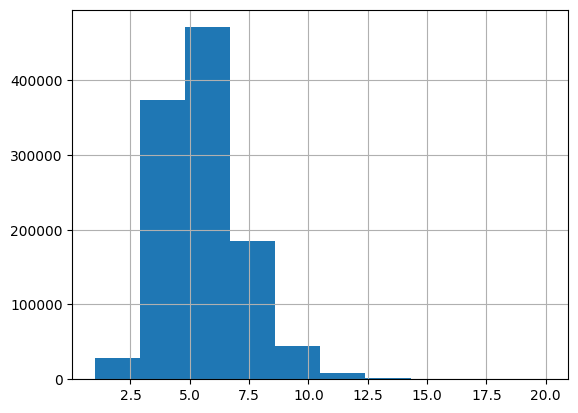

In [16]:
# from tpvalidator.algo.tafinder.dbscan import ApplyDBScan
# def apply_dbscan_wrap(*args, **kwargs):
#     n_clusters, mean_cluster_sadc, total_cluster_sadc, max_cluster_sadc = ApplyDBScan(*args, **kwargs)
#     return pd.Series({
#         "n_clusters": n_clusters,
#         "mean_cluster_sadc": mean_cluster_sadc,
#         "total_cluster_sadc": total_cluster_sadc,
#         "max_cluster_sadc": max_cluster_sadc,
#     })

### Create radiological windows and calculate entries and sum adc for each

tps = rad_tps
ro_view = 2
wins = (
    tps.query(f'readout_view == {ro_view}')
    .groupby(['event_uid', 'TPCSetID', 'tawin_id'], sort=False)
    .agg(
        n_entries=('tawin_id', "size"),
        sadc=("adc_integral", "sum"),
    )

)

# Filter windows in the inspect region
sel_wins = wins.query('sadc > 7500 & sadc < 50000')
sel_wins.n_entries.hist()
print(f"{len(wins)}, {len(sel_wins)}")

In [17]:
keys = ['event_uid', 'TPCSetID', 'tawin_id']


filtered = tps.join(sel_wins.index.to_frame(index=False).assign(_keep=True).set_index(keys),
                   on=keys)
filtered = filtered[filtered["_keep"] == True]
print(f'tps count = {len(tps)}, filtered tps count {len(filtered)}')

tps count = 21071545, filtered tps count 11448999

In [18]:
print(filtered.query(f'readout_view == {ro_view}').groupby(['event_uid', 'TPCSetID', 'tawin_id'], sort=False).ngroups)

1111505

In [19]:
from tpvalidator.algo.tafinder.trigger_algs_numba import apply_dbscan
from tqdm import tqdm
tqdm.pandas(desc="numba tafinder!")

### Create radiological windows and calculate entries and sum adc for each

tas3 = (
    filtered
    .query(f'readout_view == {ro_view}')
    .groupby(['event_uid', 'TPCSetID', 'tawin_id'], sort=False)
    .progress_apply(apply_dbscan, include_groups = False)
    .reset_index()
)

numba tafinder!: 100%|██████████| 1111505/1111505 [02:12<00:00, 8409.04it/s] 


In [20]:
tas3

# print(tas3.n_clusters.max())
# tas3.n_clusters.hist(bins=int(tas3.n_clusters.max()))

,event_uid,TPCSetID,tawin_id,n_clusters,mean_cluster_sadc,total_cluster_sadc,max_cluster_sadc,tp_index,dbscan_label
0,233339401031,0,5,0,0.0,0,0,[],[]
1,233339401031,0,6,0,0.0,0,0,[],[]
2,233339401031,0,0,1,6057.0,6057,6057,"[29, 30, 31, 32]","[0, 0, -1, -1]"
3,233339401031,1,3,1,2271.0,2271,2271,"[65, 67, 68, 69, 76]","[-1, -1, 0, 0, -1]"
4,233339401031,1,1,2,2679.0,5358,3201,"[71, 72, 82, 83, 84, 85, 86]","[-1, -1, -1, 0, 0, 1, 1]"
...,...,...,...,...,...,...,...,...,...
1111500,233789400095,45,6,0,0.0,0,0,[],[]
1111501,233789400095,46,3,0,0.0,0,0,[],[]
1111502,233789400095,46,2,0,0.0,0,0,[],[]
1111503,233789400095,47,5,0,0.0,0,0,[],[]


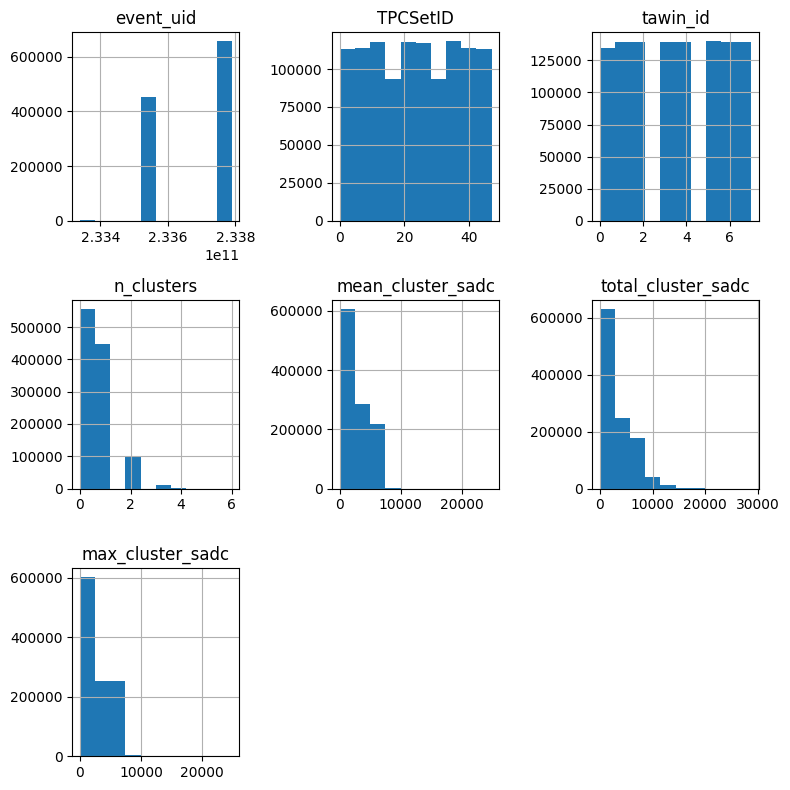

In [21]:
tas3.hist(figsize=(8,8))
plt.tight_layout()

(array([[6.5000e+01, 8.2400e+02, 2.3930e+03, 5.8430e+03, 1.0110e+04,
         1.3958e+04, 1.7257e+04, 2.0203e+04, 2.2654e+04, 2.5096e+04,
         2.6171e+04, 2.4901e+04, 2.5749e+04, 2.7522e+04, 2.7365e+04,
         2.2124e+04, 1.9924e+04, 2.0919e+04, 2.2407e+04, 2.3403e+04,
         2.4511e+04, 2.5571e+04, 2.6953e+04, 2.9355e+04, 3.0207e+04,
         2.6302e+04, 1.5850e+04, 4.6470e+03, 9.3700e+02, 4.9400e+02,
         3.2300e+02, 2.1600e+02, 1.4500e+02, 1.2500e+02, 1.0200e+02,
         6.3000e+01, 6.4000e+01, 5.7000e+01, 4.8000e+01, 3.4000e+01,
         3.0000e+01, 2.2000e+01, 1.5000e+01, 1.9000e+01, 8.0000e+00,
         1.0000e+01, 5.0000e+00, 6.0000e+00, 7.0000e+00, 1.0000e+01,
         7.0000e+00, 3.0000e+00, 6.0000e+00, 1.0000e+00, 3.0000e+00,
         2.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00, 2.0000e+00,
         0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         4.0000e+00, 0.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0

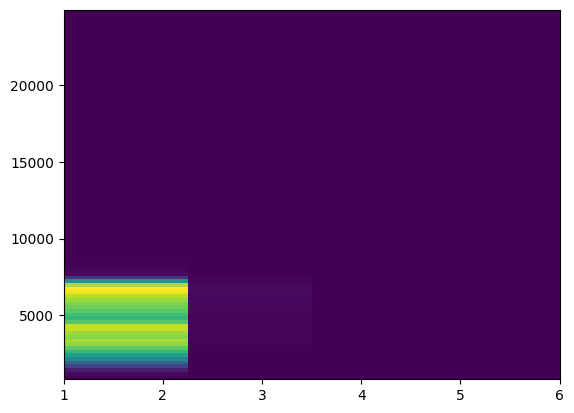

In [22]:
df = tas3.query('n_clusters > 0')

plt.hist2d(x=df.n_clusters.values, y=df.max_cluster_sadc.values,bins=(4, 100))



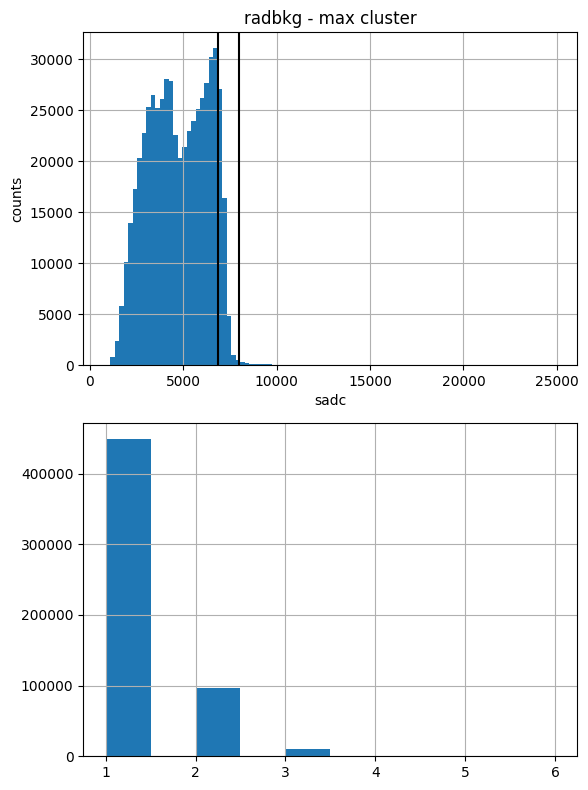

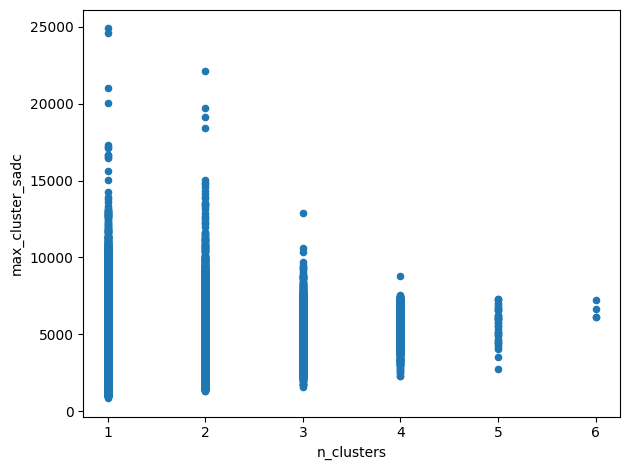

In [23]:
fig, axes = plt.subplots(2,1, figsize=(6,8))
ax=axes[0]
df.max_cluster_sadc.hist(bins=100, ax=ax)

sadc_1Mev = 2.2787e3
ax.axvline(x=sadc_1Mev*3.5, c='k')
ax.axvline(x=sadc_1Mev*3, c='k')
# ax.set_yscale('log')
ax.set_xlabel('sadc')
ax.set_ylabel('counts')
ax.set_title('radbkg - max cluster')

ax=axes[1]
df.n_clusters.hist(ax=ax)

fig.tight_layout()


fig, axes = plt.subplots(1,1)
ax=axes
df.plot.scatter(x='n_clusters', y='max_cluster_sadc', ax=ax)
fig.tight_layout()


In [24]:
rad_wins

,event_uid,TPCSetID,tawin_id,n_entries,sadc
0,233339401031,0,5,5,8382
1,233339401031,0,1,1,499
2,233339401031,0,7,3,3713
3,233339401031,0,2,3,4310
4,233339401031,0,6,8,14391
...,...,...,...,...,...
3512411,233789400095,47,4,2,2616
3512412,233789400095,47,7,6,14613
3512413,233789400095,47,3,3,3630
3512414,233789400095,47,6,2,1936


Hist(Regular(500, 0, 42275, name='sadc'), storage=Double()) # Sum: 1.0

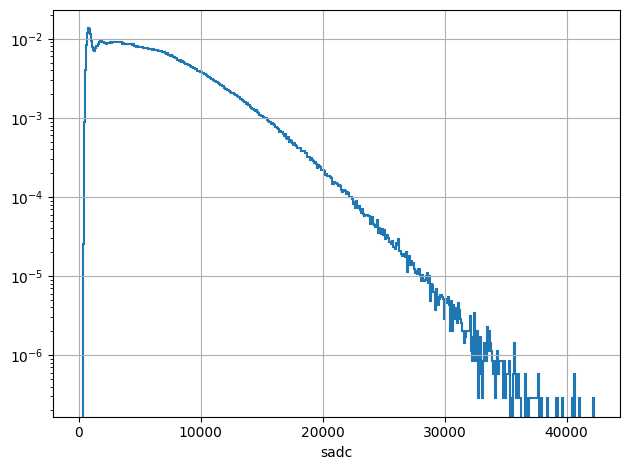

In [25]:
df = rad_wins

#----

import hist
import mplhep

xmin, xmax = df.sadc.min(), df.sadc.max()+1
xmin = 0
bins=500

h_sadc = hist.Hist(hist.axis.Regular(bins, xmin, xmax, name='sadc'), storage=hist.storage.Double())
h_sadc.fill(df.sadc.values)

values = np.asarray(h_sadc.values(flow=False), dtype=float)
h1 = h_sadc / values.sum()
display(h1)

# Save TAWindow distribution in a root file
import uproot
with uproot.recreate("1x8x6_radbkg_tawin_dist.root") as f:
    f["h1"] = h1


fig,ax = plt.subplots()#figsize=(20,10))
mplhep.histplot(h1)
ax.set_yscale('log')
ax.grid()
ax.set_xlabel('sadc')
fig.tight_layout()

Hist(Regular(500, 0, 42275, name='sadc'), storage=Double()) # Sum: 73.03970828056814

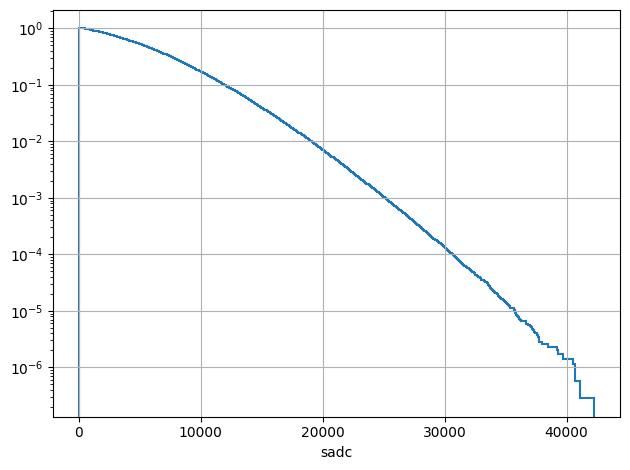

In [26]:
hint = h1.copy()
hint[:] = np.flip(np.cumsum(np.flip(h1.values())))
display(hint)

fig,ax = plt.subplots()#figsize=(20,10))
mplhep.histplot(hint)
ax.set_yscale('log')
ax.grid()
ax.set_xlabel('sadc')
fig.tight_layout()

In [27]:
from scipy.stats import rv_histogram


# extract histogram info
counts = h1.view()
edges  = h1.axes[0].edges


# create distribution
dist = rv_histogram((counts, edges))

# sample
samples = dist.rvs(size=10_000_000)

(array([2.45539e+05, 5.55737e+05, 3.81987e+05, 4.51385e+05, 4.37952e+05,
        4.47416e+05, 4.50862e+05, 4.42046e+05, 4.25566e+05, 4.24024e+05,
        3.97283e+05, 3.89019e+05, 3.78176e+05, 3.66439e+05, 3.55249e+05,
        3.42620e+05, 3.18080e+05, 2.97412e+05, 2.73661e+05, 2.53338e+05,
        2.34885e+05, 2.15375e+05, 1.97236e+05, 1.81947e+05, 1.64532e+05,
        1.49512e+05, 1.36008e+05, 1.22748e+05, 1.10651e+05, 9.99770e+04,
        8.97720e+04, 7.94740e+04, 7.14890e+04, 6.32570e+04, 5.67220e+04,
        5.02920e+04, 4.38660e+04, 3.93250e+04, 3.41500e+04, 2.98270e+04,
        2.57450e+04, 2.28010e+04, 1.96340e+04, 1.77970e+04, 1.49960e+04,
        1.31250e+04, 1.16720e+04, 9.89400e+03, 8.62700e+03, 7.34600e+03,
        6.41000e+03, 5.81200e+03, 4.62400e+03, 3.90100e+03, 3.44700e+03,
        2.77100e+03, 2.48400e+03, 2.13300e+03, 1.87600e+03, 1.57400e+03,
        1.22600e+03, 1.16500e+03, 9.64000e+02, 7.63000e+02, 7.12000e+02,
        5.63000e+02, 4.71000e+02, 4.99000e+02, 3.13

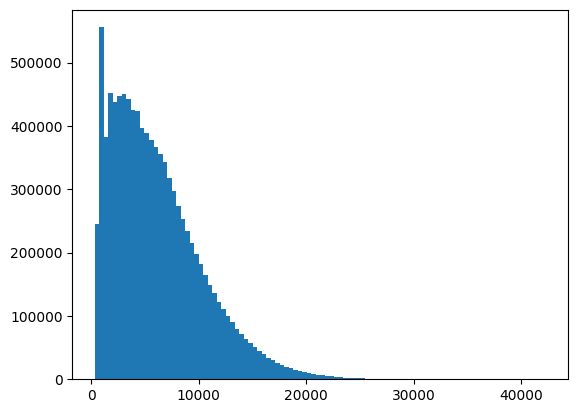

In [28]:
fig, ax = plt.subplots(1,1)

ax.hist(samples, bins=100)

In [32]:
from tpvalidator.viz.histograms import hist_quantiles, hist_mean_std_uhi

median = hist_quantiles(h_sadc, 0.5)[0]
mean, _ = hist_mean_std_uhi(h_sadc)

print(f"""
SADC median: {median:.2f}
SADC mean:   {mean:.2f}""")

print(hint[15000j])

SADC median: 5314.95
SADC mean:   6133.23

0.03989988657379992

Search window rate 1280000.0

51071.8548144639

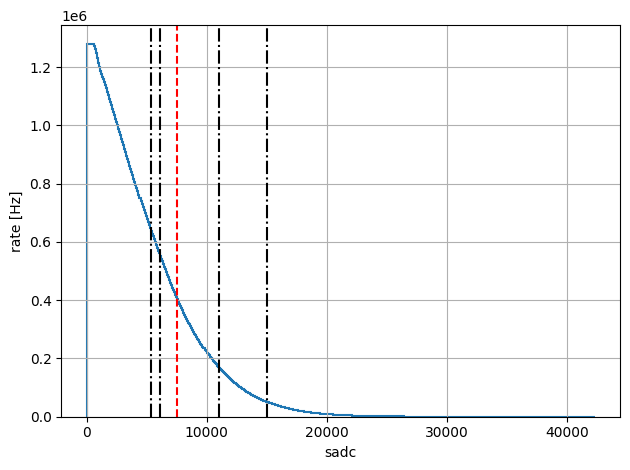

In [43]:
win_rate = 160*4/(0.5e-6*1000)
# win_rate = 4/(0.5e-6*1000)
# win_rate = 1/(0.5e-6*1000)
print(f" Search window rate {win_rate}")
fig,ax = plt.subplots()
mplhep.histplot(hint * win_rate)
# ax.set_yscale('log')
ax.grid()
ax.set_xlabel('sadc')
ax.set_ylabel('rate [Hz]')
ax.axvline(7500, c='r', ls='--')
ax.axvline(median, c='k', ls='-.')
ax.axvline(mean, c='k', ls='-.')
ax.axvline(15000, c='k', ls='-.')
ax.axvline(11000, c='k', ls='-.')
fig.tight_layout()


(hint * win_rate)[15000j]





